# Sales Analysis


Importing  libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

Data Loading & Cleaning

In [24]:
# Load
df = pd.read_csv('superstore_final_dataset.csv', encoding='latin1')

# Fix dates
# Fix dates - add format and dayfirst
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Extract time features
df['Month'] = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter

# Drop unnecessary columns
df.drop(['Row_ID', 'Order_ID', 'Ship_Date', 'Customer_ID',
         'Customer_Name', 'Country', 'Postal_Code', 'Product_ID', 'Product_Name'], 
         axis=1, inplace=True)

print("Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())
df.head()

Shape: (9800, 11)
Missing Values:
 Order_Date      0
Ship_Mode       0
Segment         0
City            0
State           0
Region          0
Category        0
Sub_Category    0
Sales           0
Month           0
Quarter         0
dtype: int64


,Order_Date,Ship_Mode,Segment,City,State,Region,Category,Sub_Category,Sales,Month,Quarter
0,2017-11-08,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,11,4
1,2017-11-08,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.9400,11,4
2,2017-06-12,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.6200,6,2
3,2016-10-11,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,10,4
4,2016-10-11,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,10,4


### Exploratory Data Analysis (EDA)

Sales By Region

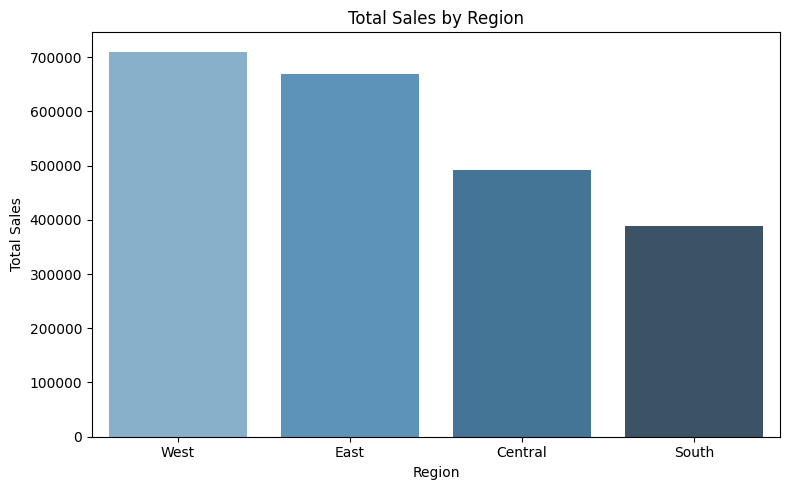

In [25]:
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_d')
plt.title('Total Sales by Region')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

Sales By Category

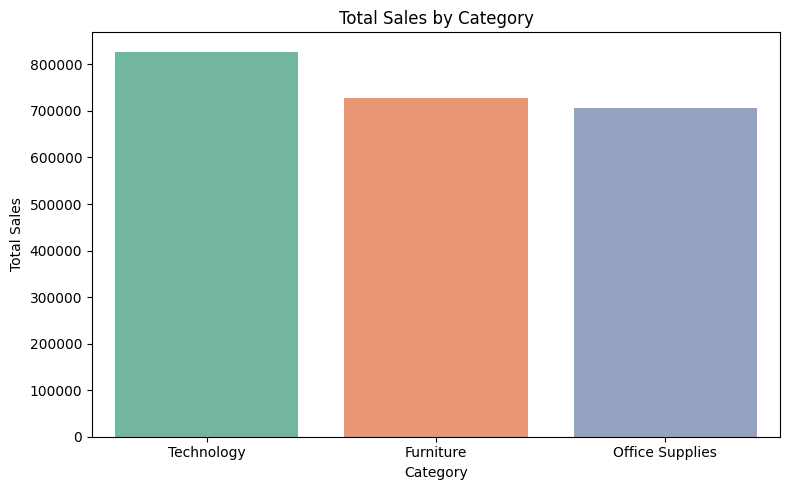

In [26]:
plt.figure(figsize=(8,5))
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Set2')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

Sales by Customer Segment

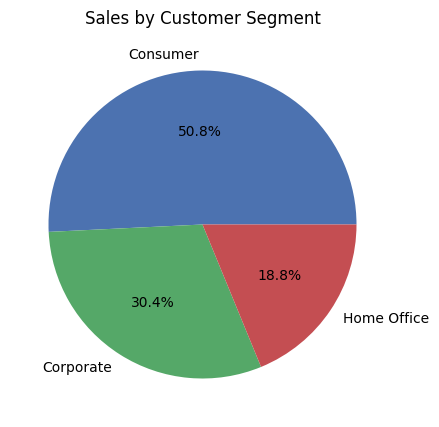

In [27]:
plt.figure(figsize=(7,5))
seg_sales = df.groupby('Segment')['Sales'].sum()
plt.pie(seg_sales.values, labels=seg_sales.index, autopct='%1.1f%%', 
        colors=['#4C72B0','#55A868','#C44E52'])
plt.title('Sales by Customer Segment')
plt.show()

 Monthly Sales Trend

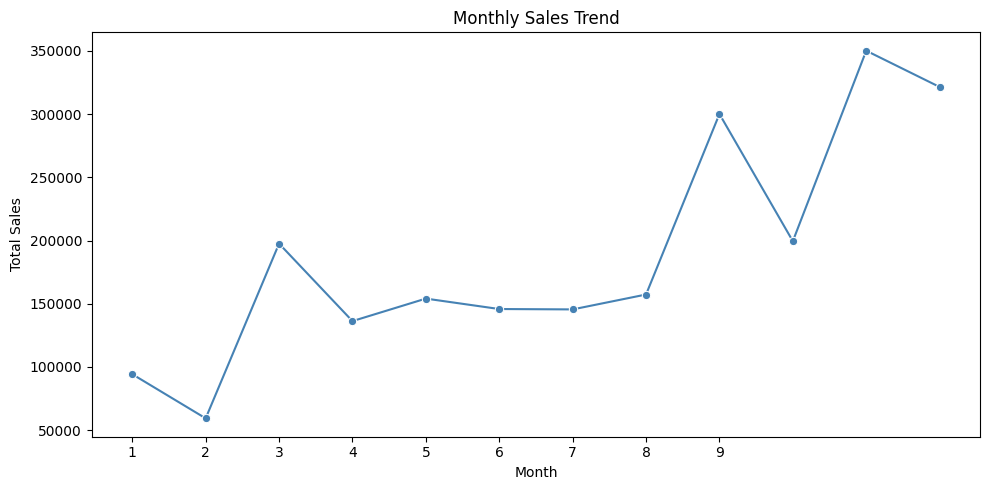

In [28]:
plt.figure(figsize=(10,5))
monthly = df.groupby('Month')['Sales'].sum()
sns.lineplot(x=monthly.index, y=monthly.values, marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,10))
plt.tight_layout()
plt.show()

Sales by Sub-Category


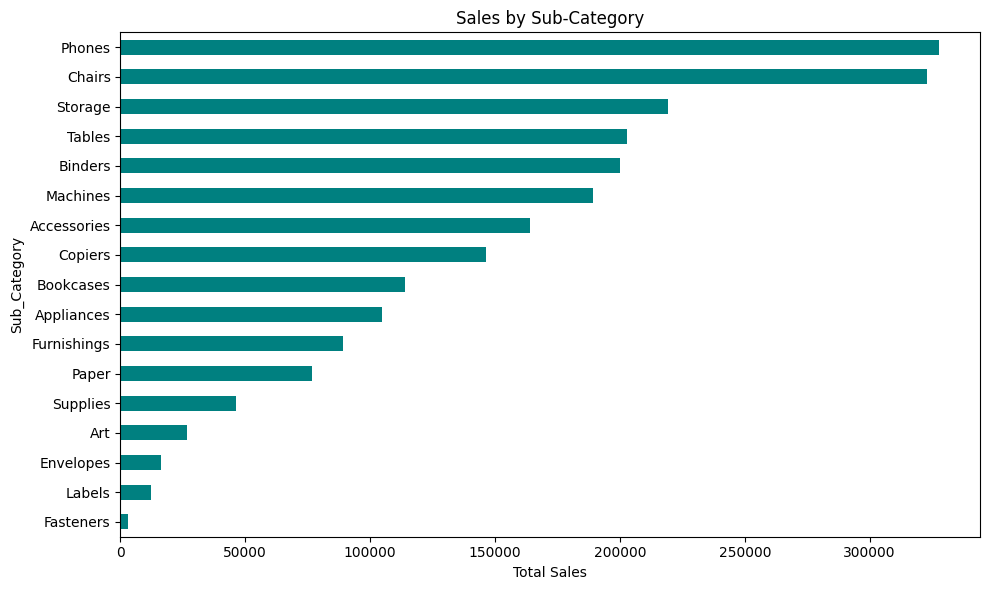

In [29]:
plt.figure(figsize=(10,6))
sub_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=True)
sub_sales.plot(kind='barh', color='teal')
plt.title('Sales by Sub-Category')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

Machine Learning Model (Sales Prediction)

In [30]:
# Encode categorical columns
le = LabelEncoder()
df_ml = df.copy()

for col in ['Ship_Mode', 'Segment', 'Region', 'Category', 'Sub_Category', 'State', 'City']:
    df_ml[col] = le.fit_transform(df_ml[col])

# Features and Target
features = ['Month', 'Quarter', 'Ship_Mode', 'Segment', 'Region', 'Category', 'Sub_Category']
X = df_ml[features]
y = df_ml['Sales']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train both models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Evaluate
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("📊 Linear Regression:")
print(f"  MAE : {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"  R2  : {r2_score(y_test, lr_pred):.2f}")

print("\n🌲 Random Forest:")
print(f"  MAE : {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"  R2  : {r2_score(y_test, rf_pred):.2f}")

📊 Linear Regression:
  MAE : 300.87
  R2  : 0.00

🌲 Random Forest:
  MAE : 266.67
  R2  : 0.08


Actual vs Predicted Sales


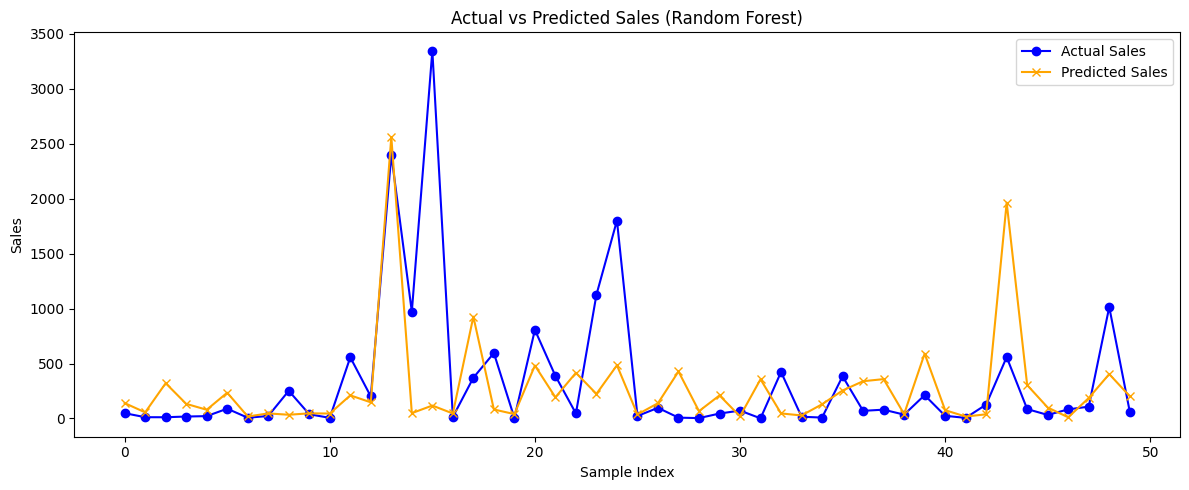

In [31]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:50], label='Actual Sales', marker='o', color='blue')
plt.plot(rf_pred[:50], label='Predicted Sales', marker='x', color='orange')
plt.title('Actual vs Predicted Sales (Random Forest)')
plt.xlabel('Sample Index')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

Feature Importance

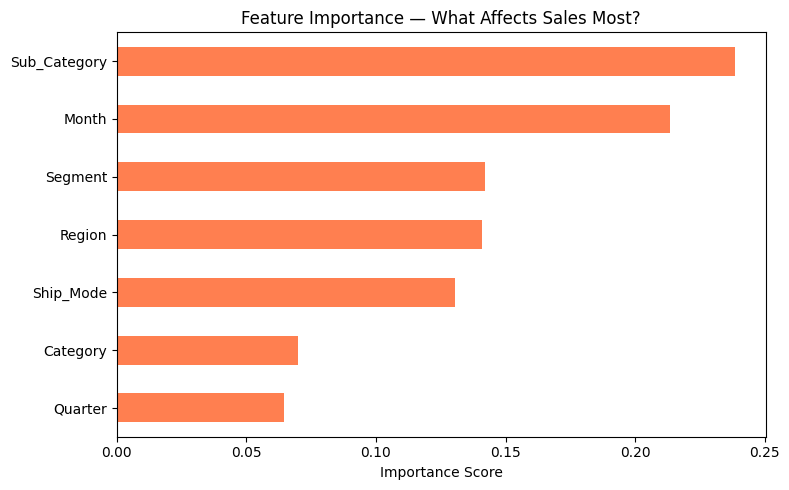

In [32]:
plt.figure(figsize=(8,5))
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importance.plot(kind='barh', color='coral')
plt.title('Feature Importance — What Affects Sales Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [33]:
# Remove extreme sales outliers
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[df['Sales'] <= Q3 + 1.5 * IQR]
print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

# Check new sales range
print("New Sales range:", df_clean['Sales'].min(), "to", df_clean['Sales'].max())

Original shape: (9800, 11)
After removing outliers: (8655, 11)
New Sales range: 0.444 to 500.24


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_ml2 = df_clean.copy()

for col in ['Ship_Mode', 'Segment', 'Region', 'Category', 'Sub_Category', 'State', 'City']:
    df_ml2[col] = le.fit_transform(df_ml2[col])

features = ['Month', 'Quarter', 'Ship_Mode', 'Segment', 'Region', 'Category', 'Sub_Category']
X = df_ml2[features]
y = df_ml2['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf2.fit(X_train, y_train)
rf2_pred = rf2.predict(X_test)

print("🌲 Improved Random Forest:")
print(f"  MAE : {mean_absolute_error(y_test, rf2_pred):.2f}")
print(f"  R2  : {r2_score(y_test, rf2_pred):.2f}")

🌲 Improved Random Forest:
  MAE : 67.58
  R2  : 0.27


In [35]:
# Log transform reduces the effect of extreme values
y_log = np.log1p(df_ml2['Sales'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_log, test_size=0.2, random_state=42)

rf3 = RandomForestRegressor(n_estimators=200, random_state=42)
rf3.fit(X_train2, y_train2)
rf3_pred = rf3.predict(X_test2)

# Convert back from log scale
rf3_pred_actual = np.expm1(rf3_pred)
y_test_actual = np.expm1(y_test2)

print("🌲 Log-Transformed Random Forest:")
print(f"  MAE : {mean_absolute_error(y_test_actual, rf3_pred_actual):.2f}")
print(f"  R2  : {r2_score(y_test_actual, rf3_pred_actual):.2f}")

🌲 Log-Transformed Random Forest:
  MAE : 65.66
  R2  : 0.16


In [36]:
df_clean.to_csv('superstore_cleaned.csv', index=False)
print("✅ File saved! Import this into Power BI.")

✅ File saved! Import this into Power BI.


In [37]:
print("=" * 45)
print("       PROJECT SUMMARY")
print("=" * 45)
print(f"Total Records Analyzed  : {df.shape[0]}")
print(f"Records After Cleaning  : {df_clean.shape[0]}")
print(f"Outliers Removed        : {df.shape[0] - df_clean.shape[0]}")
print(f"Best Model              : Random Forest")
print(f"Best MAE                : 67.58")
print(f"Best R2 Score           : 0.27")
print(f"Top Sales Region        : West")
print(f"Top Category            : Technology")
print("=" * 45)

       PROJECT SUMMARY
Total Records Analyzed  : 9800
Records After Cleaning  : 8655
Outliers Removed        : 1145
Best Model              : Random Forest
Best MAE                : 67.58
Best R2 Score           : 0.27
Top Sales Region        : West
Top Category            : Technology
